In [11]:
# Add import 
import sys

import numpy as np
import torch 
from torch import nn
from torch import optim
import tqdm
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")

%matplotlib inline
# allow reload of python modules
%load_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy
from dataset import RobotPathDataset
from model.loss import WeightedLoss, ObstacleFreePathLoss
plt.close('all') 
# matplotlib.use('Agg')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()
CONFIG = {
    # Model configuration
    'representation_dim': 64,
    # Hyperparameters for training
    'batch_size': 32,
    'num_epochs': 100,
    'learning_rate': 0.001,
    'optimizer': optim.Adam,
    # Hyperparameters for diffusion process
    'noise_steps': 100,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'scheduler': optim.lr_scheduler.ExponentialLR,
    'ema': EMA(0.99),
    'scheduler_gamma': 0.999,

    # Dataset specific configuration
    'n_paths_per_world': 1000,
    'n_worlds': 100,
    'n_waypoints': 64,
}

In [3]:
file = '/home/karim.samir.lotfy/adlr/tum-adlr-ss24-09/data/SingleSphere02_all.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

/home/karim.samir.lotfy/adlr/tum-adlr-ss24-09/dataset/RobotPathDataset/torch_dataset.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(path_coordinates, device=device) # torch tensor


data shape: torch.Size([16000, 64, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:28, samples: 16000
 sample shape torch.Size([64, 2]) with 16000 samples


# Test Normalizer and Denormalizer

In [ ]:
# get a sample from the dataset
indx = 0
sample = dataset[indx]
path = sample['path']
denormalized_path = CONFIG['normalizer'].denormalize(path).detach().cpu().numpy()
og_path = sample['og_path'].detach().cpu().numpy()
# plot the path
plt.figure()
plt.plot(denormalized_path[:, 0], denormalized_path[:, 1], label='denormalized_path')
plt.plot(og_path[:, 0], og_path[:, 1], label='og_path')
plt.legend()

In [ ]:
og_path - denormalized_path

In [ ]:
# plot 10 random index samples
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(2):
    for j in range(5):
        indx = np.random.randint(len(dataset))
        sample = dataset[indx]
        sample['path'] = CONFIG['normalizer'].denormalize(sample['path']).cpu().numpy()
        sample['world_img'] = sample['world_img']
        axs[i, j].plot(sample['path'][:, 0], sample['path'][:, 1])
        axs[i, j].imshow(sample['world_img'].T, extent=[0, 10, 0, 10], origin='lower', cmap='binary')


In [ ]:
sample = dataset[indx]
dimg = sample['world_distance_field_img']
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
# show the value of colors 
plt.colorbar()

In [ ]:
dimg

## Analyse nature of dimg

In [ ]:
# get hostogram of values 
# sample many points from the dataset
values = []
for i in range(100):
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img']
    values.extend(dimg.flatten());
plt.hist(values, bins=100);

In [ ]:
normalizer = MinMaxFeatureNormalizer()
# min_values are a 64 * 64 array filled with -1
min_values = np.ones((64, 64)) * -1
# max_values are a 64 * 64 array filled with 3.5
max_values = np.ones((64, 64)) * 3.5
normalizer.initialize(min_values=min_values, max_values=max_values)

In [ ]:
# try to normalize the values using torch layernorm
dimg = torch.tensor(dimg, device='cuda').float()
dimg = normalizer.normalize(dimg)
dimg = dimg.flatten()
dimg = dimg.reshape(64, 64)
plt.imshow(dimg.cpu().detach().numpy().T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.colorbar()

In [ ]:
# get hostogram of values 
# sample many points from the dataset
values = []
for i in range(100):
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img']
    # try to normalize the values using torch layernorm
    dimg = torch.tensor(dimg, device='cuda').float()
    dimg = normalizer.normalize(dimg)
    dimg = dimg.flatten()
    dimg = dimg.cpu().detach().numpy()
    values.extend(dimg);
plt.hist(values, bins=100);

In [ ]:
# get hostogram of values 
# sample many points from the dataset
values = []
for i in range(100):
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img']
    # try to normalize the values using torch layernorm
    dimg = torch.tensor(dimg).float()
    norm = nn.LayerNorm(dimg.shape)
    dimg = norm(dimg)
    dimg = dimg.flatten()
    dimg = dimg.cpu().detach().numpy()
    values.extend(dimg);
plt.hist(values, bins=100);

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
indx = 12
print(indx)
sample = dataset[indx]
sample['path'] = CONFIG['normalizer'].denormalize(sample['path']).cpu().numpy()
sample = dataset.get_og_item(indx)
sample['path'] = sample['path'].cpu().numpy()
sample['world_img'] = sample['world_img']
axs[0, 0].plot(sample['path'][:, 0], sample['path'][:, 1], '-o')
axs[0, 0].imshow(sample['world_img'].T, extent=[-0, 10, -0, 10], origin='lower', cmap='binary')
fig.show()

# NEW LOSS FUNCTIONS

## obstacle free loss

In [ ]:
indx = np.random.randint(len(dataset))
# get a random sample 
sample = dataset[indx]
dimg = sample['world_distance_field_img']
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')

In [ ]:
# draw path on top of the distance field
path = sample['og_path'].cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path[:, 0], path[:, 1], '-o', color='red')

In [ ]:
loss = ObstacleFreePathLoss(normalizer=None)

In [ ]:
indx = np.random.randint(len(dataset))
sample = dataset[indx]
dimg = sample['world_distance_field_img'].to('cuda')
path = sample['og_path']
path = path.unsqueeze(0)
dimg = dimg.unsqueeze(0)
l = loss(path, dimg)
l

In [ ]:
for i in range(10): # plot 10 paths and their distance field
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = loss(path, dimg)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    plt.plot(path[:, 0], path[:, 1], '-o', color='red')
    plt.title(f'loss {l}')
    plt.show()

In [ ]:
for i in range(10):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = loss(path, dimg)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * 0.8
    path = path + noise
    l = loss(path, dimg)
    dimg = sample['world_distance_field_img']
    path = path.cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path[0, :, 0], path[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')

In [ ]:

# create my own 2 point path
path = torch.tensor([[2, 6.1], [4, 4]], device='cuda').float()
path = path.unsqueeze(0)
path.requires_grad = True
dimg = sample['world_distance_field_img'].to('cuda')
dimg = dimg.unsqueeze(0)
l = loss(path, dimg)
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'loss {l}')

In [ ]:
# show the path after the optimization
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'path after optimization')

In [ ]:
# take 100 steps of optimization
optimizer = optim.Adam([path], lr=0.01)
for i in range(100):
    dimg = sample['world_distance_field_img'].to('cuda')
    dimg = dimg.unsqueeze(0)
    l = loss(path, dimg)
    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    if i % 10 == 0:
        print(f'loss {l}')

In [ ]:
path

In [ ]:
# show the path after the optimization
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'path after optimization')

In [ ]:
path = torch.tensor([[2, 6.1], [4, 4]], device='cuda').float()
path = path.unsqueeze(0)
path.requires_grad = True
path_true_points = torch.tensor([[[4, 8], [6.5, 4.5]]], device='cuda').float()


In [ ]:
# take 100 steps of optimization
optimizer = optim.Adam([path], lr=0.01)
for i in range(100):
    dimg = sample['world_distance_field_img'].to('cuda')
    dimg = dimg.unsqueeze(0)
    l1 = loss(path, dimg)
    l2 = nn.MSELoss()(path, path_true_points)
    l = l1 + l2
    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    if i % 10 == 0:
        print(f'loss {l}')

In [ ]:
# show the path after the optimization
dimg = sample['world_distance_field_img']
path_vis = path.cpu().detach().numpy()
plt.imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
plt.plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
plt.title(f'path after optimization')

In [ ]:
path

### Average preformance of ground truth

In [ ]:
loss = ObstacleFreePathLoss(normalizer=None)

In [ ]:
# get the average loss for the dataset with sampling
losses = []
for i in dataset:
    dimg = i['world_distance_field_img'].to('cuda')
    dimg = dimg.unsqueeze(0)
    path = i['og_path']
    path = path.unsqueeze(0)
    l = loss(path, dimg)
    losses.append(l.cpu().detach().numpy())

In [ ]:
print(f'average loss obstacle free path for entire DB {np.mean(losses)}')

In [ ]:
losses = []
for i in dataset:
    dimg = i['world_distance_field_img'].to('cuda')
    dimg = dimg.unsqueeze(0)
    path = torch.rand_like(i['og_path']).to('cuda') * 10
    path = path.unsqueeze(0)
    noise = torch.randn_like(path) * 0.8
    path = path + noise
    l = loss(path, dimg)
    losses.append(l.cpu().detach().numpy())

# print the std of the loss
print(f'std loss obstacle free path for entire DB {np.std(losses)}')

## Loss for waypoint consitency


In [ ]:
import torch
import torch.nn as nn

from model.loss import GraphBasedConsistencyLoss
loss_fn = GraphBasedConsistencyLoss()

In [ ]:
for i in range(10):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = loss_fn(path)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['og_path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * 0.8
    path = path + noise
    l = loss_fn(path)
    dimg = sample['world_distance_field_img']
    path = path.cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path[0, :, 0], path[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')

In [ ]:
loss = GraphBasedConsistencyLoss()

In [ ]:
# get the average loss for the dataset 
losses = []
for i in dataset:
    dimg = i['world_distance_field_img'].to('cuda')
    dimg = dimg.unsqueeze(0)
    path = i['og_path']
    path = path.unsqueeze(0)
    l = loss_fn(path)
    losses.append(l.cpu().detach().numpy())

In [ ]:
print(f'average loss waypoint smoothness for entire DB {np.mean(losses)}')

In [ ]:
losses = []
for i in dataset:
    dimg = i['world_distance_field_img'].to('cuda')
    dimg = dimg.unsqueeze(0)
    path = torch.rand_like(i['og_path']).to('cuda') * 10
    path = path.unsqueeze(0)
    noise = torch.randn_like(path) * 0.8
    path = path + noise
    l = loss(path)
    losses.append(l.cpu().detach().numpy())

# print the std of the loss
print(f'std loss obstacle free path for entire DB {np.std(losses)}')

# Positional encoding the start and end 

In [ ]:
from model.model_blocks import SinusoidalPosEmb

In [ ]:
time = torch.tensor([1, 2, 3])
embeder = SinusoidalPosEmb(32)
embeder(time)

In [ ]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, d):
        """
        Args:
            d (int): Dimension of the embedding. Must be a multiple of 4.
        """
        super(SinusoidalEmbedding, self).__init__()
        assert d % 4 == 0, "Dimension d must be a multiple of 4."
        self.d = d
        self.half_d = d // 2

        # Precompute the div_term
        even_indices = torch.arange(0, self.half_d, 2).float()
        self.div_term = torch.exp(even_indices * (-torch.log(torch.tensor(10000.0)) / self.half_d))

    def forward(self, points):
        """
        Args:
            points (torch.Tensor): Tensor of shape (Batch, Waypoints, 2) containing x and y coordinates.
        
        Returns:
            torch.Tensor: Sinusoidal embeddings of shape (Batch, Waypoints, d).
        """
        batch_size, num_waypoints, _ = points.shape
        
        x = points[:, :, 0]  # (Batch, Waypoints)
        y = points[:, :, 1]  # (Batch, Waypoints)
        
        # Sinusoidal embedding for x
        x_embedding = torch.zeros(batch_size, num_waypoints, self.half_d, device=points.device)
        x_embedding[:, :, 0::2] = torch.sin(x.unsqueeze(-1) * self.div_term)
        x_embedding[:, :, 1::2] = torch.cos(x.unsqueeze(-1) * self.div_term)
        
        # Sinusoidal embedding for y
        y_embedding = torch.zeros(batch_size, num_waypoints, self.half_d, device=points.device)
        y_embedding[:, :, 0::2] = torch.sin(y.unsqueeze(-1) * self.div_term)
        y_embedding[:, :, 1::2] = torch.cos(y.unsqueeze(-1) * self.div_term)
        
        # Concatenate x and y embeddings
        embedding = torch.cat([x_embedding, y_embedding], dim=-1)
        
        return embedding

In [ ]:
points = torch.tensor([[[1.0, 3.0], [2.0, 2.0], [3.0, 5.0]],
                        [[3.0, 1.0], [2.0, 2.0], [3.0, 4.0]]], dtype=torch.float32)

d = 4  # Must be a multiple of 4

embedding = SinusoidalEmbedding(d)(points)
embedding.shape

In [ ]:
embeddings_np = embedding.cpu().detach().numpy()
# Plot each dimension of the embeddings
for i in range(embeddings_np.shape[1]):
    plt.plot(embeddings_np[:, i], label=f'Dimension {i+1}')

plt.legend()
plt.show()

In [ ]:
import torch
import math

class SinusoidalPositionalEncoding1D(torch.nn.Module):
    def __init__(self, embed_dim, max_len=5000):
        super(SinusoidalPositionalEncoding1D, self).__init__()
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return x

class SinusoidalPositionalEncoding2D(torch.nn.Module):
    def __init__(self, embed_dim, height, width):
        super(SinusoidalPositionalEncoding2D, self).__init__()
        pe = torch.zeros(height, width, embed_dim)
        
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        
        pos_h = torch.arange(0, height).unsqueeze(1)
        pos_w = torch.arange(0, width).unsqueeze(1)
        
        pe[0::2, :, :] = torch.sin(pos_h * div_term).unsqueeze(2) + torch.sin(pos_w * div_term).unsqueeze(1)
        pe[1::2, :, :] = torch.cos(pos_h * div_term).unsqueeze(2) + torch.cos(pos_w * div_term).unsqueeze(1)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(2), :x.size(3)]
        return x


In [ ]:
import matplotlib.pyplot as plt
embed_dim=32
max_len = 256
def visualize_positional_encoding_1d(pe, length=100):
    plt.figure(figsize=(15, 5))
    pe = pe[:length].detach().numpy()
    for i in range(pe.shape[1]):
        plt.plot(pe[:, i], label=f'Dim {i}')
    plt.legend(loc='upper right')
    plt.title('1D Positional Encoding')
    plt.xlabel('Position')
    plt.ylabel('Encoding value')
    plt.show()

# Assuming `embed_dim` and `max_len` are defined
pe_1d = SinusoidalPositionalEncoding1D(embed_dim, max_len).pe.squeeze(1)
visualize_positional_encoding_1d(pe_1d, length=100)


In [ ]:
import numpy as np
from positional_encodings.torch_encodings import PositionalEncoding1D, PositionalEncoding2D, PositionalEncoding3D, Summer

p_enc_2d = PositionalEncoding2D(8)
height = 10
width = 10
def visualize_positional_encoding_2d(pe, height, width):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    pe = pe.detach().numpy()
    
    # Plot the first and second channels of the positional encoding
    axes[0].imshow(pe[0, :, :], cmap='viridis')
    axes[0].set_title('Positional Encoding (Channel 0)')
    axes[1].imshow(pe[1, :, :], cmap='viridis')
    axes[1].set_title('Positional Encoding (Channel 1)')
    
    plt.show()

import torch

# Create a random input tensor of shape (1, 1, 4, 4) with integers from 0 to 9
inputs = torch.randint(0, 10, (1, 1, 4, 4))
print(inputs)

p_enc_2d(inputs)

# Relative encodings

### Criteria 
* diffrentiable
* gives more precision the closer you are 
* allows model to predict 0, 0 to be the straignt line. already making it a way better prediction 
* maybe allow model to change the scal dynamically

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Adjusted logarithmic mapping function
def adjusted_log_mapping(x, k=10):
    return np.sign(x) * (11 * np.log(k * np.abs(x) + 1) / np.log(k + 1))

# Generate x values from -1 to 1
x = np.linspace(-1, 1, 500)

# Calculate y values for different k values
k_values = [1, 2, 5, 10, 20, 100]
y_values = [adjusted_log_mapping(x, k) for k in k_values]

# Plot the results
plt.figure(figsize=(10, 6))
for k, y in zip(k_values, y_values):
    plt.plot(x, y, label=f'k = {k}')

plt.xlabel('Model Output [-1, 1]')
plt.ylabel('Mapped Output [-10, 10]')
plt.title('Adjusted Logarithmic Mapping with Different k Values')
plt.legend()
plt.grid(True)
plt.show()


### Dataset post processing to create mapping
* Assume u have n_waypoints on straigtline from start and end
* give me the path in terms of offset to that straight line

In [ ]:
import wzk
from wzk import trajectory
indx = 80
sample = dataset[indx]
path = sample['path'].detach().cpu().numpy()
path
path_with_only_start_and_end = path[[0, -1]]
path_with_only_start_and_end
straight_line = trajectory.get_path_adjusted(path_with_only_start_and_end, n=20)
# Get the relaive offset of the straight line
offset_path = path - straight_line
offset_path

In [ ]:
# plot the path and the straight line
plt.plot(path[:, 0], path[:, 1], '-o', label='Original Path')
plt.plot(straight_line[:, 0], straight_line[:, 1], '-o', label='Straight Line')
plt.plot(offset_path[:, 0], offset_path[:, 1], '-o', label='Offset Path')

In [ ]:
(path == straight_line + offset_path)
path - straight_line - offset_path

Guassian Basis Encoding

In [ ]:
indx = 3
sample = dataset[indx]
world_binary_img = sample['world_img']
# show the binary image
plt.imshow(world_binary_img.T, origin='lower', extent=[0, 10, 0, 10], cmap='binary')

In [16]:
from functools import partial
import multiprocessing
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm

def generate_random_basis(n_points=1000, n_dims=3, radius=1.0, random_seed=13):
    """Sample uniformly from d-dimensional unit ball

    The code is inspired by this small note:
    https://blogs.sas.com/content/iml/2016/04/06/generate-points-uniformly-in-ball.html

    Parameters
    ----------
    n_points : int
        number of samples
    n_dims : int
        number of dimensions
    radius: float
        ball radius
    random_seed: int
        random seed for basis point selection
    Returns
    -------
    x : numpy array
        points sampled from d-ball
    """
    np.random.seed(random_seed)
    # sample point from d-sphere
    x = np.random.normal(size=[n_points, n_dims])
    x_norms = np.sqrt(np.sum(np.square(x), axis=1)).reshape([-1, 1])
    x_unit = x / x_norms

    # now sample radiuses uniformly
    r = np.random.uniform(size=[n_points, 1])
    u = np.power(r, 1.0 / n_dims)
    x = radius * x_unit * u
    np.random.seed(None)

    return x


def generate_grid_basis(grid_size=32, n_dims=3, minv=-1.0, maxv=1.0):
    """ Generate d-dimensional grid BPS basis

    Parameters
    ----------
    grid_size: int
        number of elements in each grid axe
    minv: float
        minimum element of the grid
    maxv
        maximum element of the grid

    Returns
    -------
    basis: numpy array [grid_size**n_dims, n_dims]
        n-d grid points
    """

    linspaces = [np.linspace(minv, maxv, num=grid_size) for d in range(0, n_dims)]
    coords = np.meshgrid(*linspaces)
    basis = np.concatenate([coords[i].reshape([-1, 1]) for i in range(0, n_dims)], axis=1)

    return basis


def encode(x, bps_arrangement='random', n_bps_points=512, radius=1.5, bps_cell_type='dists',
           verbose=1, random_seed=13, x_features=None, custom_basis=None, n_jobs=-1):
    """Converts point clouds to basis point set (BPS) representation, multi-processing version

    Parameters
    ----------
    x: numpy array [n_clouds, n_points, n_dims]
        batch of point clouds to be converted
    bps_arrangement: str
        supported BPS arrangements: "random", "grid", "custom"
    n_bps_points: int
        number of basis points
    radius: float
        radius for BPS sampling area
    bps_cell_type: str
        type of information stored in every BPS cell. Supported:
            'dists': Euclidean distance to the nearest point in cloud
            'deltas': delta vector from basis point to the nearest point
            'closest': closest point itself
            'features': return features of the closest point supplied by x_features.
                        e.g. RGB values of points, surface normals, etc.
    verbose: boolean
        whether to show conversion progress
    x_features: numpy array [n_clouds, n_points, n_features]
        point features that will be stored in BPS cells if return_values=='features'
    custom_basis: numpy array [n_basis_points, n_dims]
        custom basis to use
    n_jobs: int
        number of parallel jobs used for encoding. If -1, use all available CPUs

    Returns
    -------
    x_bps: [n_clouds, n_points, n_bps_features]
        point clouds converted to BPS representation.
    """

    if n_jobs == -1:
        n_jobs = multiprocessing.cpu_count()

    if n_jobs == 1:

        n_clouds, n_points, n_dims = x.shape

        if bps_arrangement == 'random':
            basis_set = generate_random_basis(n_bps_points, n_dims=n_dims, radius=radius, random_seed=random_seed)
        elif bps_arrangement == 'grid':
            # in case of a grid basis, we need to find the nearest possible grid size
            grid_size = int(np.round(np.power(n_bps_points, 1 / n_dims)))
            basis_set = generate_grid_basis(grid_size=grid_size, minv=-radius, maxv=radius)
        elif bps_arrangement == 'custom':
            # in case of a grid basis, we need to find the nearest possible grid size
            if custom_basis is not None:
                basis_set = custom_basis
            else:
                raise ValueError("Custom BPS arrangement selected, but no custom_basis provided.")
        else:
            raise ValueError("Invalid basis type. Supported types: \'random\', \'grid\', \'custom\'")

        n_bps_points = basis_set.shape[0]

        if bps_cell_type == 'dists':
            x_bps = np.zeros([n_clouds, n_bps_points])
        elif bps_cell_type == 'deltas':
            x_bps = np.zeros([n_clouds, n_bps_points, n_dims])
        elif bps_cell_type == 'closest':
            x_bps = np.zeros([n_clouds, n_bps_points, n_dims])
        elif bps_cell_type == 'features':
            n_features = x_features.shape[2]
            x_bps = np.zeros([n_clouds, n_bps_points, n_features])
        else:
            raise ValueError("Invalid cell type. Supported types: \'dists\', \'deltas\', \'closest\', \'features\'")
        fid_lst = range(0, n_clouds)

        if verbose:
            fid_lst = tqdm(fid_lst)

        for fid in fid_lst:
            nbrs = NearestNeighbors(n_neighbors=1, leaf_size=1, algorithm="ball_tree").fit(x[fid])
            fid_dist, npts_ix = nbrs.kneighbors(basis_set)

            if bps_cell_type == 'dists':
                x_bps[fid] = fid_dist.squeeze()
            elif bps_cell_type == 'deltas':
                x_bps[fid] = x[fid][npts_ix].squeeze() - basis_set
            elif bps_cell_type == 'closest':
                x_bps[fid] = x[fid][npts_ix].squeeze()
            elif bps_cell_type == 'features':
                x_bps[fid] = x_features[fid][npts_ix].squeeze()

        return x_bps

    else:

        if verbose:
            print("using %d available CPUs for BPS encoding.." % n_jobs)

        bps_encode_func = partial(encode, bps_arrangement=bps_arrangement, n_bps_points=n_bps_points, radius=radius,
                                  bps_cell_type=bps_cell_type, verbose=verbose, random_seed=random_seed,
                                  x_features=x_features, custom_basis=custom_basis, n_jobs=1)

        pool = multiprocessing.Pool(n_jobs)
        x_chunks = np.array_split(x, n_jobs)
        x_bps = np.concatenate(pool.map(bps_encode_func, x_chunks), 0)
        pool.close()

        return x_bps

In [ ]:
from functools import partial
import multiprocessing
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm

def normalize(x, known_scalers=False, x_mean=None, x_max=None, max_rescale=True, return_scalers=False, verbose=False):
    def _normalize_cloud(x, max_rescale=True, x_mean=None, x_max=None):
        if x_mean is None:
            x_mean = np.mean(x, axis=0)
        x_norm = np.copy(x - x_mean)
        if x_max is None:
            if max_rescale:
                x_max = np.max(np.sqrt(np.sum(np.square(x_norm), axis=1)))
            else:
                x_max = 1.0
        x_norm = x_norm / x_max
        return x_norm, x_mean, x_max

    n_clouds, n_points, n_dims = x.shape
    x_norm = np.zeros([n_clouds, n_points, n_dims])

    if known_scalers is False:
        x_mean = np.zeros([n_clouds, n_dims])
        x_max = np.zeros([n_clouds, 1])

    fid_lst = range(0, n_clouds)
    if verbose:
        fid_lst = tqdm(fid_lst)

    for pid in fid_lst:
        if known_scalers is False:
            x_norm[pid], x_mean[pid], x_max[pid] = _normalize_cloud(x[pid], max_rescale=max_rescale)
        else:
            x_norm[pid], _, _ = _normalize_cloud(x[pid], max_rescale=max_rescale, x_mean=x_mean[pid], x_max=x_max[pid])

    if return_scalers:
        return x_norm, x_mean, x_max
    else:
        return x_norm



In [ ]:
# give it the bianry world image 
point_cloud_from_img = np.argwhere(world_binary_img)
encoded = encode(world_binary_img, bps_arrangement='grid', n_bps_points=32, radius=1.5, bps_cell_type='dists', verbose=1, random_seed=13, x_features=None, custom_basis=None, n_jobs=1)


In [15]:
data = torch.randn(100, 10)
test = torch.randn(3, 10)

dist2 = torch.norm(data.unsqueeze(1) - test.unsqueeze(0), dim=2, p=None)
knn = dist2.topk(3, largest=False, dim=0)


print('kNN dist: {}, index: {}'.format(knn.values, knn.indices))

kNN dist: tensor([[1.9292, 2.2744, 1.8329],
        [2.6468, 2.3576, 2.5314],
        [2.7305, 2.3848, 2.5629]]), index: tensor([[ 8, 36, 85],
        [ 7, 35, 36],
        [17, 91,  8]])


In [6]:
from sklearn.neighbors import NearestNeighbors
from functools import partial

def generate_random_basis(n_points=1000, n_dims=3, radius=1.0, random_seed=13, device='cpu'):
    """Sample uniformly from d-dimensional unit ball using PyTorch

    Parameters
    ----------
    n_points : int
        number of samples
    n_dims : int
        number of dimensions
    radius: float
        ball radius
    random_seed: int
        random seed for basis point selection
    device: str
        PyTorch device to use ('cpu' or 'cuda')
    Returns
    -------
    x : torch tensor
        points sampled from d-ball
    """
    torch.manual_seed(random_seed)
    # sample point from d-sphere
    x = torch.randn(n_points, n_dims, device=device)
    x_norms = torch.sqrt(torch.sum(x**2, axis=1)).reshape([-1, 1])
    x_unit = x / x_norms

    # now sample radiuses uniformly
    r = torch.rand(n_points, 1, device=device)
    u = torch.pow(r, 1.0 / n_dims)
    x = radius * x_unit * u
    torch.manual_seed(torch.initial_seed() & 0xFFFFFFFF)

    return x


def generate_grid_basis(grid_size=32, n_dims=3, minv=-1.0, maxv=1.0, device='cpu'):
    """ Generate d-dimensional grid BPS basis using PyTorch

    Parameters
    ----------
    grid_size: int
        number of elements in each grid axe
    minv: float
        minimum element of the grid
    maxv
        maximum element of the grid
    device: str
        PyTorch device to use ('cpu' or 'cuda')

    Returns
    -------
    basis: torch tensor [grid_size**n_dims, n_dims]
        n-d grid points
    """
    linspaces = [torch.linspace(minv, maxv, grid_size, device=device) for _ in range(n_dims)]
    coords = torch.meshgrid(*linspaces)
    basis = torch.cat([coord.reshape(-1, 1) for coord in coords], dim=1)

    return basis


def encode(x, bps_arrangement='random', n_bps_points=512, radius=1.5, bps_cell_type='dists',
           verbose=1, random_seed=13, x_features=None, custom_basis=None, n_jobs=1, device='cpu'):
    """Converts point clouds to basis point set (BPS) representation, multi-processing version

    Parameters
    ----------
    x: torch tensor [n_clouds, n_points, n_dims]
        batch of point clouds to be converted
    bps_arrangement: str
        supported BPS arrangements: "random", "grid", "custom"
    n_bps_points: int
        number of basis points
    radius: float
        radius for BPS sampling area
    bps_cell_type: str
        type of information stored in every BPS cell. Supported:
            'dists': Euclidean distance to the nearest point in cloud
            'deltas': delta vector from basis point to the nearest point
            'closest': closest point itself
            'features': return features of the closest point supplied by x_features.
                        e.g. RGB values of points, surface normals, etc.
    verbose: boolean
        whether to show conversion progress
    x_features: torch tensor [n_clouds, n_points, n_features]
        point features that will be stored in BPS cells if return_values=='features'
    custom_basis: torch tensor [n_basis_points, n_dims]
        custom basis to use
    n_jobs: int
        number of parallel jobs used for encoding. If -1, use all available CPUs
    device: str
        PyTorch device to use ('cpu' or 'cuda')

    Returns
    -------
    x_bps: torch tensor [n_clouds, n_points, n_bps_features]
        point clouds converted to BPS representation.
    """

    if n_jobs == -1:
        n_jobs = multiprocessing.cpu_count()

    if n_jobs == 1:

        n_clouds, n_points, n_dims = x.shape

        if bps_arrangement == 'random':
            basis_set = generate_random_basis(n_bps_points, n_dims=n_dims, radius=radius, random_seed=random_seed, device=device)
        elif bps_arrangement == 'grid':
            # in case of a grid basis, we need to find the nearest possible grid size
            grid_size = int(round(pow(n_bps_points, 1 / n_dims)))
            basis_set = generate_grid_basis(grid_size=grid_size, minv=-radius, maxv=radius, device=device)
            print('basis_set: ', basis_set)
        elif bps_arrangement == 'custom':
            # in case of a grid basis, we need to find the nearest possible grid size
            if custom_basis is not None:
                basis_set = custom_basis.to(device)
            else:
                raise ValueError("Custom BPS arrangement selected, but no custom_basis provided.")
        else:
            raise ValueError("Invalid basis type. Supported types: 'random', 'grid', 'custom'")

        n_bps_points = basis_set.shape[0]

        if bps_cell_type == 'dists':
            x_bps = torch.zeros([n_clouds, n_bps_points], device=device)
        elif bps_cell_type == 'deltas':
            x_bps = torch.zeros([n_clouds, n_bps_points, n_dims], device=device)
        elif bps_cell_type == 'closest':
            x_bps = torch.zeros([n_clouds, n_bps_points, n_dims], device=device)
        elif bps_cell_type == 'features':
            n_features = x_features.shape[2]
            x_bps = torch.zeros([n_clouds, n_bps_points, n_features], device=device)
        else:
            raise ValueError("Invalid cell type. Supported types: 'dists', 'deltas', 'closest', 'features'")
        fid_lst = range(0, n_clouds)

        if verbose:
            fid_lst = tqdm(fid_lst)

        for fid in fid_lst: 
            dist = torch.norm(x[fid].unsqueeze(1) - basis_set.unsqueeze(0), dim=2, p=None)
            knn = dist.topk(3, largest=False, dim=0)

            fid_dist, npts_ix = knn.values, knn.indices

            fid_dist = torch.tensor(fid_dist, device=device)
            npts_ix = torch.tensor(npts_ix, device=device)

            if bps_cell_type == 'dists':
                x_bps[fid] = fid_dist.squeeze()
            elif bps_cell_type == 'deltas':
                x_bps[fid] = x[fid][npts_ix].squeeze() - basis_set
            elif bps_cell_type == 'closest':
                x_bps[fid] = x[fid][npts_ix].squeeze()
            elif bps_cell_type == 'features':
                x_bps[fid] = x_features[fid][npts_ix].squeeze()

        return x_bps

    else:

        if verbose:
            print("using %d available CPUs for BPS encoding.." % n_jobs)

        bps_encode_func = partial(encode, bps_arrangement=bps_arrangement, n_bps_points=n_bps_points, radius=radius,
                                  bps_cell_type=bps_cell_type, verbose=verbose, random_seed=random_seed,
                                  x_features=x_features, custom_basis=custom_basis, n_jobs=1, device=device)

        pool = multiprocessing.Pool(n_jobs)
        x_chunks = torch.chunk(x, n_jobs)
        x_bps_chunks = pool.map(bps_encode_func, x_chunks)
        x_bps = torch.cat(x_bps_chunks, dim=0)
        pool.close()

        return x_bps


In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [8]:
n_bps_points = 64
n_dims = 2
grid_size = int(round(pow(n_bps_points, 1 / n_dims)))
print(grid_size)
basis_set = generate_grid_basis(grid_size=grid_size, n_dims=n_dims,minv=0, maxv=64, device=device)
print('basis_set: ', basis_set.shape)

basis_set_vis = basis_set.cpu().detach().numpy()
# plot the basis set
plt.scatter(basis_set_vis[:, 0], basis_set_vis[:, 1])

8
basis_set:  torch.Size([64, 2])


/opt/conda/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


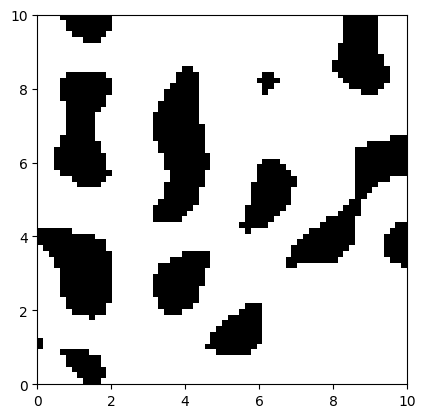

In [13]:
indx = 6
sample = dataset[indx]
world_binary_img = sample['world_img']
# show the binary image
plt.imshow(world_binary_img.T, origin='lower', extent=[0, 10, 0, 10], cmap='binary')

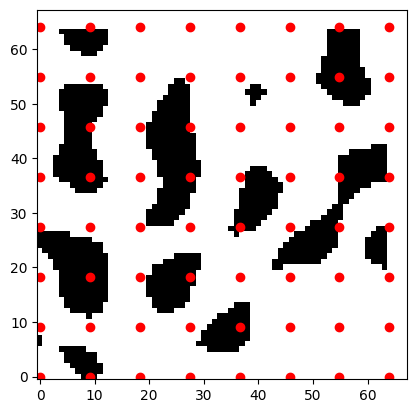

In [12]:
# plot the world and the basis set
plt.imshow(world_binary_img.T, origin='lower', cmap='binary')
plt.scatter(basis_set_vis[:, 0], basis_set_vis[:, 1], color='red')

In [24]:
# get all points from the binary image
world_binary_img = torch.tensor(world_binary_img, device='cuda')
world_binary_img_1 = torch.tensor(dataset[6006]['world_img'], device='cuda')
world_binary_img_2 = torch.tensor(dataset[1007]['world_img'], device='cuda')
batch_world_binary_img = torch.stack([world_binary_img_1, world_binary_img_2], dim=0)
# Ensure the batch dimension is preserved in the output
batch_size = batch_world_binary_img.shape[0]
indices_list = []

values = []
# Perform argwhere on each image in the batch and add batch indices
for i in range(batch_size):
    img_indices = torch.argwhere(batch_world_binary_img[i])
    dist = torch.norm(img_indices.unsqueeze(1) - basis_set.unsqueeze(0), dim=2)

    # 3. Find the nearest neighbors (top-1 smallest distance)
    #    We want to find the nearest point in `x` for each basis_set point across the batch
    knn = dist.topk(1, largest=False, dim=0)
    values.append(knn.values[0, :])

values = torch.stack(values, dim=0)
values.shape

/var/tmp/ipykernel_114131/3817971158.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  world_binary_img = torch.tensor(world_binary_img, device='cuda')


torch.Size([2, 64])

In [112]:
import torch

# Define device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Generate synthetic point cloud data
def generate_synthetic_point_clouds(n_clouds=10, n_points=1000, n_dims=3, radius=1.0, random_seed=13, device='cpu'):
    torch.manual_seed(random_seed)
    point_clouds = torch.randn(n_clouds, n_points, n_dims, device=device) * radius
    return point_clouds

# Generate synthetic point features
def generate_synthetic_point_features(n_clouds=10, n_points=1000, n_features=3, random_seed=13, device='cpu'):
    torch.manual_seed(random_seed)
    point_features = torch.randn(n_clouds, n_points, n_features, device=device)
    return point_features

# Generate point clouds and features
n_clouds, n_points, n_dims, radius = 10, 1000, 3, 1.0
n_features = 3
point_clouds = generate_synthetic_point_clouds(n_clouds=n_clouds, n_points=n_points, n_dims=n_dims, radius=radius, device=device)
point_features = generate_synthetic_point_features(n_clouds=n_clouds, n_points=n_points, n_features=n_features, device=device)

# Test encode function with different configurations
encoded_clouds_dists = encode(point_clouds, bps_arrangement='random', n_bps_points=512, radius=1.5, bps_cell_type='dists', device=device)
print('Encoded point clouds with distances:', encoded_clouds_dists.shape)

encoded_clouds_deltas = encode(point_clouds, bps_arrangement='grid', n_bps_points=512, radius=1.5, bps_cell_type='deltas', device=device)
print('Encoded point clouds with deltas:', encoded_clouds_deltas.shape)

encoded_clouds_closest = encode(point_clouds, bps_arrangement='custom', n_bps_points=512, radius=1.5, bps_cell_type='closest', custom_basis=generate_random_basis(512, n_dims=3, radius=1.5, device=device), device=device)
print('Encoded point clouds with closest points:', encoded_clouds_closest.shape)

encoded_clouds_features = encode(point_clouds, bps_arrangement='random', n_bps_points=512, radius=1.5, bps_cell_type='features', x_features=point_features, device=device)
print('Encoded point clouds with features:', encoded_clouds_features.shape)


TypeError: 'module' object is not callable